**Project ID=** PRAICP-1012

**Project =** Pneumonia chest x-ray classification using CNN

 ## 1.Import the Necessary Libraries :

In [4]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


import os: Import the os module for interacting with the operating system (e.g., file path manipulations).

import shutil: Import the shutil module for file operations like copying and moving files.

import numpy as np: Import the numpy library, commonly used for numerical computations and handling arrays.

import pandas as pd: Import the pandas library for data manipulation and analysis.

import matplotlib.pyplot as plt: Import matplotlib's pyplot module for creating visualizations and plots.

import tensorflow as tf: Import the tensorflow library for building and training machine learning models.

In [5]:
from tensorflow.keras.models import Sequential

In [6]:
from tensorflow.keras.layers import Conv2D,Dropout,Dense,MaxPooling2D,Flatten

In [12]:
from tensorflow.keras.activations import sigmoid

In [7]:
from tensorflow.keras.activations import relu,softmax,sigmoid
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential: Import Sequential to create a linear stack of layers for the neural network.
    
from tensorflow.keras.layers import Conv2D,Dropout,Dense,MaxPooling2D,Flatten: Import common neural network layers for building CNNs (convolution, pooling, fully connected, etc.).
    
from tensorflow.keras.activations import sigmoid: Import the sigmoid activation function used for binary classification or certain neural layers.
    
from tensorflow.keras.activations import relu,softmax,sigmoid: Import relu, softmax, and sigmoid activation functions for various layers and purposes.
    
from tensorflow.keras.optimizers import Adam: Import the Adam optimizer, a popular optimization algorithm for training neural networks.
    
from tensorflow.keras.preprocessing.image import ImageDataGenerator: Import ImageDataGenerator for loading, preprocessing, and augmenting image data.

## 2.Import the CSC File:

In [37]:
import cv2
import os

# Define the path to the directory containing images
image_dir = r'C:\Project\chest_xray\train\NORMAL'

# List all image files in the directory
image_files = os.listdir(image_dir)

# Read the first image and check its size
first_image_path = os.path.join(image_dir, image_files[1])
img = cv2.imread(first_image_path)
height, width, channels = img.shape
print(f"Image size: {width}x{height}, Channels: {channels}")

Image size: 2090x1858, Channels: 3


In [38]:
img

array([[[ 22,  22,  22],
        [ 24,  24,  24],
        [ 24,  24,  24],
        ...,
        [ 96,  96,  96],
        [ 94,  94,  94],
        [ 93,  93,  93]],

       [[ 23,  23,  23],
        [ 24,  24,  24],
        [ 24,  24,  24],
        ...,
        [ 97,  97,  97],
        [ 94,  94,  94],
        [ 92,  92,  92]],

       [[ 24,  24,  24],
        [ 24,  24,  24],
        [ 23,  23,  23],
        ...,
        [ 99,  99,  99],
        [ 96,  96,  96],
        [ 94,  94,  94]],

       ...,

       [[ 49,  49,  49],
        [ 50,  50,  50],
        [ 48,  48,  48],
        ...,
        [119, 119, 119],
        [119, 119, 119],
        [119, 119, 119]],

       [[ 50,  50,  50],
        [ 52,  52,  52],
        [ 53,  53,  53],
        ...,
        [123, 123, 123],
        [124, 124, 124],
        [123, 123, 123]],

       [[ 52,  52,  52],
        [ 53,  53,  53],
        [ 54,  54,  54],
        ...,
        [129, 129, 129],
        [128, 128, 128],
        [127, 127, 127]]

## 3.Normalize the Pixels and Pre-Processing:

In [8]:
datagen=ImageDataGenerator(rescale=1./255,# Normalize pixel values
    shear_range=0.2,# Shear transformation
    zoom_range=0.2,# Randomly zoom in on images
    channel_shift_range=0.2,
    rotation_range=0.2,# Randomly rotate images
    width_shift_range=0.2,# Randomly translate images horizontally
    height_shift_range=0.2,# Randomly translate images vertically
    validation_split=0.2,# train and test split
     fill_mode='nearest'  # Fill mode for new pixels                       
    )

## 4.Import the train and Validation file path;

In [9]:
train_generator=datagen.flow_from_directory(r'C:\Users\DELL\Desktop\Kaggle Project xlxe\DataMites  - AI Capstone Projects-19.12.2024\PRAICP-1012-Chest Xray\chest_xray\train',target_size=(150,150),batch_size=30)
validation_generator=datagen.flow_from_directory(r'C:\Users\DELL\Desktop\Kaggle Project xlxe\DataMites  - AI Capstone Projects-19.12.2024\PRAICP-1012-Chest Xray\chest_xray\val',target_size=(150,150),batch_size=30)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


## Insights :
'path_to_training_data', # Directory containing training images

target_size=(128, 128), # Resize all images to 128x128

batch_size=32, # Batch size

In [10]:
train_generator

## 5.Import the Model:

In [13]:
model=Sequential([
    Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(150,150,3)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=128,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=256,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(units=512,activation='relu'),
    Dropout(0.5),
    Dense(len(train_generator.class_indices),activation='sigmoid')
])

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Insights :
image_height and image_width should match the dimensions of the images after they have been resized, not their original size.

channels should match the number of color channels in your images (e.g., 3 for RGB images, 1 for grayscale).

## 6.Compile the Model:

In [14]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

## 7.Model Summary:

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 15, 15, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       6,423,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │           1,026 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,812,482 (25.99 MB)

 Trainable params: 6,812,482 (25.99 MB)

 Non-trainable params: 0 (0.00 B)

## 8.train the Model to be check accuracy:

In [16]:
history=model.fit(train_generator,epochs=25,validation_data=validation_generator)
history

Epoch 1/25


C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


174/174 ━━━━━━━━━━━━━━━━━━━━ 301s 2s/step - accuracy: 0.7302 - loss: 0.5795 - val_accuracy: 0.5000 - val_loss: 1.3313
Epoch 2/25
174/174 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.7836 - loss: 0.4508 - val_accuracy: 0.6875 - val_loss: 0.5580
Epoch 3/25
174/174 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.8625 - loss: 0.3295 - val_accuracy: 0.7500 - val_loss: 1.9724
Epoch 4/25
174/174 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.8756 - loss: 0.2770 - val_accuracy: 0.7500 - val_loss: 0.8645
Epoch 5/25
174/174 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.9019 - loss: 0.2378 - val_accuracy: 0.6875 - val_loss: 0.9284
Epoch 6/25
174/174 ━━━━━━━━━━━━━━━━━━━━ 290s 2s/step - accuracy: 0.9064 - loss: 0.2241 - val_accuracy: 0.7500 - val_loss: 0.6737
Epoch 7/25
174/174 ━━━━━━━━━━━━━━━━━━━━ 299s 2s/step - accuracy: 0.9157 - loss: 0.2047 - val_accuracy: 0.6875 - val_loss: 0.7416
Epoch 8/25
174/174 ━━━━━━━━━━━━━━━━━━━━ 274s 2s/step - accuracy: 0.9157 - loss: 0.2000 - val_accuracy: 0.625

## Insights :
Train_generator: Ensure your images are preprocessed (e.g., normalized and resized) and labels are one-hot encoded for multi-class classification.

EPOCHS: Use best score due to Hyper Parameter.

Validation: Use validation data to monitor the model's performance during training to prevent overfitting.

## 9.Evaluation of Model:

In [17]:
model.evaluate(validation_generator)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.7500 - loss: 0.8170


[0.8169631958007812, 0.75]

## 10.To visualize the images to be Predict the Model:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


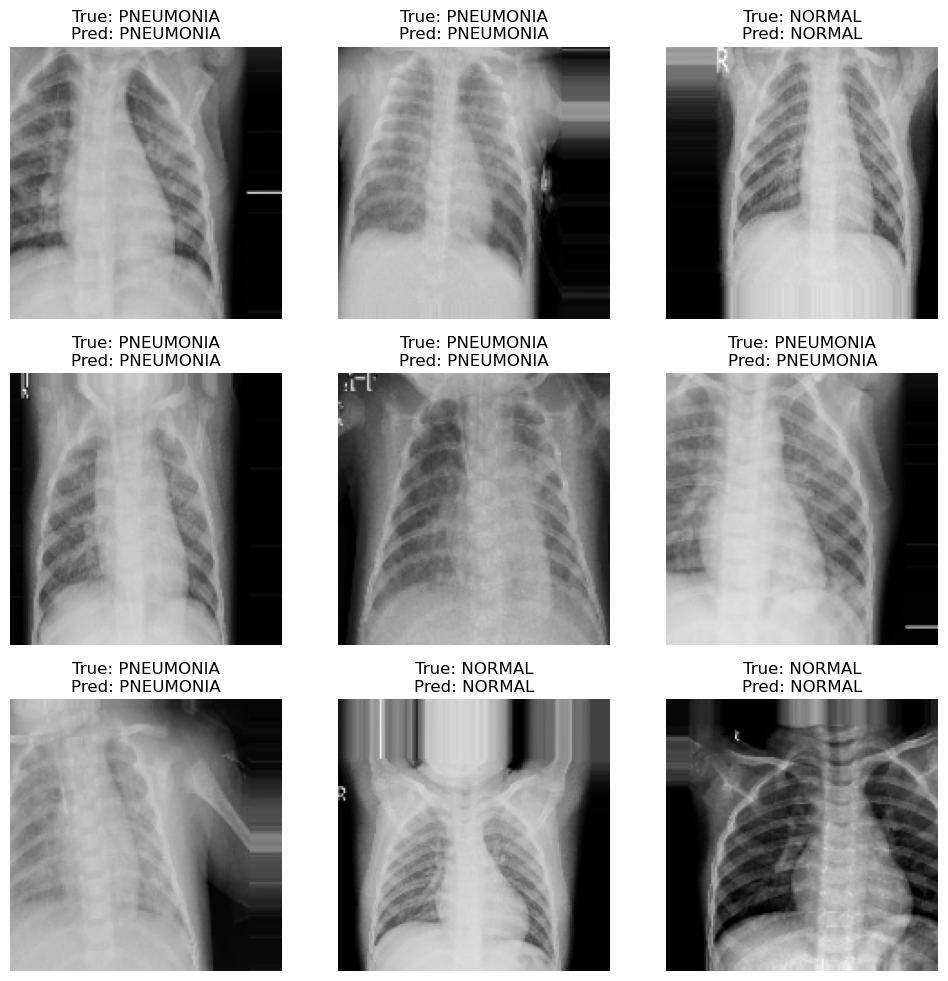

In [24]:
from tensorflow.keras.preprocessing import image

# Get a batch of images from the test set
test_images, test_labels = next(validation_generator)
predictions = model.predict(test_images)

# Convert predictions and labels to human-readable format
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(test_labels, axis=1)
class_labels = list(validation_generator.class_indices.keys())

# Plot some test images with their predicted and true labels
def plot_images(images, true_labels, predicted_labels, class_labels):
    plt.figure(figsize=(12, 12))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i])
        plt.title(f"True: {class_labels[true_labels[i]]}\nPred: {class_labels[predicted_labels[i]]}")
        plt.axis('off')
    plt.show()

# Plotting the predictions
plot_images(test_images, true_classes, predicted_classes, class_labels)


## Conclusion :
Summarize the overall impact of the project, reinforcing the importance of leveraging deep learning in medical imaging to enhance diagnostic accuracy and improve patient outcomes.